## 1: Memuat Data dan Standardisasi Format Tanggal
* Sel ini berfungsi untuk membaca dataset pelanggan utama dari berkas `customer_accounts.csv`.
* Teks pada kolom `plan_type` diseragamkan dengan diubah menjadi format huruf kecil.
* Sistem membuat variabel target bernama `is_churn` yang diisi dengan angka 1 jika pelanggan memiliki informasi pada kolom `unsubscribed_date`, dan diisi dengan angka 0 jika dibiarkan kosong.
* Data tambahan dimuat dari empat tabel transaksi pendukung: `monthly_usage_metrics.csv`, `support_tickets.csv`, `nps_surveys.csv`, dan `billing_data.csv`.
* Seluruh kolom yang mengandung nilai tanggal di dalam kelima tabel tersebut dikonversi menjadi tipe data `datetime` menggunakan `pd.to_datetime` untuk mempermudah operasi perhitungan waktu.

In [ ]:
import pandas as pd
import numpy as np

# ==========================================
# 1. load data & benerin tabel utama (accounts)
# ==========================================
print("load data customer accounts...")
df_accounts = pd.read_csv('customer_accounts.csv')
df_accounts['plan_type'] = df_accounts['plan_type'].str.lower()
df_accounts['is_churn'] = df_accounts['unsubscribed_date'].notna().astype(int)

df_accounts['subscription_date'] = pd.to_datetime(df_accounts['subscription_date'], format='mixed', dayfirst=True)
df_accounts['unsubscribed_date'] = pd.to_datetime(df_accounts['unsubscribed_date'], format='mixed', dayfirst=True)

# ==========================================
# 2. benerin format tanggal di tabel lain
# ==========================================
print("load tabel transaksi lainnya...")
df_usage = pd.read_csv('monthly_usage_metrics.csv')
df_tickets = pd.read_csv('support_tickets.csv')
df_nps = pd.read_csv('nps_surveys.csv')
df_billing = pd.read_csv('billing_data.csv')

df_usage['last_login_date'] = pd.to_datetime(df_usage['last_login_date'], format='mixed', dayfirst=True)
df_tickets['created_date'] = pd.to_datetime(df_tickets['created_date'], format='mixed', dayfirst=True)
df_nps['survey_date'] = pd.to_datetime(df_nps['survey_date'], format='mixed', dayfirst=True)
df_billing['billing_date'] = pd.to_datetime(df_billing['billing_date'], format='mixed', dayfirst=True)
df_billing['payment_date'] = pd.to_datetime(df_billing['payment_date'], format='mixed', dayfirst=True)

print("semua format tanggal udah aman!")

load data customer accounts...
load tabel transaksi lainnya...
semua format tanggal udah aman!


## 2: Pencegahan Kebocoran Data, Agregasi, dan Penggabungan
* Kode memuat ulang dan menormalisasi format tanggal seperti pada Sel 1, dengan tambahan logika pemrosesan fitur.
* Fungsi kustom bernama `filter_masa_depan` dibangun untuk menyaring dan membuang transaksi yang tercatat setelah tanggal pelanggan berhenti berlangganan, sehingga model terhindar dari bias kebocoran data (*data leakage*).
* Proses agregasi diterapkan pada data yang sudah tervalidasi untuk merangkum riwayat klien, seperti menghitung rata-rata jam penggunaan, total jumlah tiket, rata-rata skor NPS, jumlah nominal pembayaran, dan total peringatan tunggakan (`dunning`).
* Algoritma membentuk fitur baru, yaitu `delay_hari` untuk melihat tren keterlambatan tagihan, dan `usage_per_user` yang menghitung rata-rata penggunaan dibagi jumlah total pengguna di satu akun.
* Seluruh data transaksi yang diringkas digabungkan secara sentral ke tabel utama (`df_master`) menggunakan metode *Left Join* berdasarkan pengenal `customer_id`.
* Penanganan nilai kosong (*missing values*) dilakukan dengan mengimputasi angka 0 untuk fitur transaksional (seperti tiket, dunning, dan nilai pembayaran), serta mengimputasi nilai median untuk skor NPS dan intensitas penggunaan.
* Tahap akhir mengekspor 3000 baris data yang telah bersih dan terintegrasi ke dalam dokumen `master_data_clean.csv`.

In [ ]:
import pandas as pd
import numpy as np

# ==========================================
# 1. load data & benerin tabel utama (accounts)
# ==========================================
print("load data customer accounts...")
df_accounts = pd.read_csv('customer_accounts.csv')
df_accounts['plan_type'] = df_accounts['plan_type'].str.lower()
df_accounts['is_churn'] = df_accounts['unsubscribed_date'].notna().astype(int)

df_accounts['subscription_date'] = pd.to_datetime(df_accounts['subscription_date'], format='mixed', dayfirst=True)
df_accounts['unsubscribed_date'] = pd.to_datetime(df_accounts['unsubscribed_date'], format='mixed', dayfirst=True)

# ==========================================
# 2. benerin format tanggal di tabel lain
# ==========================================
print("load tabel transaksi lainnya...")
df_usage = pd.read_csv('monthly_usage_metrics.csv')
df_tickets = pd.read_csv('support_tickets.csv')
df_nps = pd.read_csv('nps_surveys.csv')
df_billing = pd.read_csv('billing_data.csv')

df_usage['last_login_date'] = pd.to_datetime(df_usage['last_login_date'], format='mixed', dayfirst=True)
df_tickets['created_date'] = pd.to_datetime(df_tickets['created_date'], format='mixed', dayfirst=True)
df_nps['survey_date'] = pd.to_datetime(df_nps['survey_date'], format='mixed', dayfirst=True)
df_billing['billing_date'] = pd.to_datetime(df_billing['billing_date'], format='mixed', dayfirst=True)
df_billing['payment_date'] = pd.to_datetime(df_billing['payment_date'], format='mixed', dayfirst=True)

# ==========================================
# 3. agregasi dengan anti-kebocoran (no data leakage)
# ==========================================
print("mulai memfilter dan meringkas data transaksi...")
df_churn_date = df_accounts[['customer_id', 'unsubscribed_date']]

def filter_masa_depan(df_transaksi, kolom_tanggal):
    df_temp = df_transaksi.merge(df_churn_date, on='customer_id', how='left')
    kondisi_valid = (df_temp[kolom_tanggal] <= df_temp['unsubscribed_date']) | (df_temp['unsubscribed_date'].isna())
    return df_temp[kondisi_valid].copy()

df_usage_valid = filter_masa_depan(df_usage, 'last_login_date')
df_tickets_valid = filter_masa_depan(df_tickets, 'created_date')
df_nps_valid = filter_masa_depan(df_nps, 'survey_date')
df_billing_valid = filter_masa_depan(df_billing, 'payment_date')

# a. meringkas usage
df_usage_agg = df_usage_valid.groupby('customer_id').agg(
    avg_usage_hrs=('monthly_usage_hrs', 'mean'),
    avg_feature_adoption=('feature_adoption_pct', 'mean'),
    last_login=('last_login_date', 'max')
).reset_index()

# b. meringkas tiket
df_tickets_agg = df_tickets_valid.groupby('customer_id').agg(
    total_tickets=('ticket_id', 'count')
).reset_index()

# c. meringkas nps
df_nps_agg = df_nps_valid.groupby('customer_id').agg(
    avg_nps_score=('nps_score', 'mean')
).reset_index()

# d. meringkas tagihan (DITAMBAH FITUR PAYMENT DELAY)
df_billing_valid['delay_hari'] = (df_billing_valid['payment_date'] - df_billing_valid['billing_date']).dt.days

df_payment = df_billing_valid[df_billing_valid['record_type'] == 'payment'].groupby('customer_id').agg(
    total_payment_value=('payment_value', 'sum'),
    avg_payment_delay=('delay_hari', 'mean')
).reset_index()

df_dunning = df_billing_valid[df_billing_valid['record_type'] == 'dunning'].groupby('customer_id').agg(
    total_dunning=('record_type', 'count')
).reset_index()

# ==========================================
# 4. gabungin semua ke tabel utama
# ==========================================
print("menggabungkan tabel (left join)...")
df_master = df_accounts.copy()

df_master = df_master.merge(df_usage_agg, on='customer_id', how='left')
df_master = df_master.merge(df_tickets_agg, on='customer_id', how='left')
df_master = df_master.merge(df_nps_agg, on='customer_id', how='left')
df_master = df_master.merge(df_payment, on='customer_id', how='left')
df_master = df_master.merge(df_dunning, on='customer_id', how='left')

# (DITAMBAH FITUR USAGE PER USER SETELAH DIGABUNG)
df_master['usage_per_user'] = df_master['avg_usage_hrs'] / df_master['total_users'].replace(0, 1)

# ==========================================
# 5. imputasi missing values
# ==========================================
df_master['total_tickets'] = df_master['total_tickets'].fillna(0)
df_master['total_dunning'] = df_master['total_dunning'].fillna(0)
df_master['avg_payment_delay'] = df_master['avg_payment_delay'].fillna(0) # imputasi fitur baru
df_master['total_payment_value'] = df_master['total_payment_value'].fillna(0)

median_nps = df_master['avg_nps_score'].median()
df_master['avg_nps_score'] = df_master['avg_nps_score'].fillna(median_nps)

df_master['avg_usage_hrs'] = df_master['avg_usage_hrs'].fillna(df_master['avg_usage_hrs'].median())
df_master['avg_feature_adoption'] = df_master['avg_feature_adoption'].fillna(df_master['avg_feature_adoption'].median())
df_master['usage_per_user'] = df_master['usage_per_user'].fillna(df_master['usage_per_user'].median()) # imputasi fitur baru

print("sukses! total baris data sekarang:", df_master.shape[0])
df_master.to_csv('master_data_clean.csv', index=False)
print("file master_data_clean.csv berhasil disimpan lengkap dengan fitur baru!")

# imputasi buat fitur telat bayar (kalau ga ada data tagihan, anggap aja telatnya 0 hari)
df_master['avg_payment_delay'] = df_master['avg_payment_delay'].fillna(0)

# imputasi buat usage per user (pake nilai median aja)
df_master['usage_per_user'] = df_master['usage_per_user'].fillna(df_master['usage_per_user'].median())

load data customer accounts...
load tabel transaksi lainnya...
mulai memfilter dan meringkas data transaksi...
menggabungkan tabel (left join)...
sukses! total baris data sekarang: 3000
file master_data_clean.csv berhasil disimpan lengkap dengan fitur baru!


## 3: Visualisasi Eksplorasi Data Awal (EDA)
Sel ini memuat dua visualisasi esensial untuk memeriksa kualitas dan karakteristik data setelah dibersihkan:
1. **Distribusi Kelas Target (Churn vs Bertahan):** Diagram batang ini menunjukkan proporsi jumlah pelanggan yang melakukan *churn* dibandingkan dengan yang bertahan. Visualisasi ini krusial untuk mengonfirmasi apakah dataset mengalami ketidakseimbangan kelas (*imbalanced data*), yang menjadi alasan mengapa algoritma SMOTE nantinya digunakan pada tahap pemodelan.
2. **Peta Panas Korelasi (Correlation Heatmap):** Diagram ini menampilkan nilai korelasi linear antara seluruh fitur numerik hasil agregasi (seperti rata-rata jam penggunaan, keterlambatan pembayaran) terhadap status *churn*. Fitur dengan nilai korelasi positif atau negatif yang kuat dapat memberikan indikasi awal mengenai faktor apa saja yang paling memengaruhi keputusan pelanggan untuk berhenti berlangganan.

In [3]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


📊 VISUALISASI 1: Distribusi Kelas Target


C:\Users\ASUS\AppData\Local\Temp\ipykernel_31836\3906633123.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_master, x='is_churn', palette=['#2ecc71', '#e74c3c'])


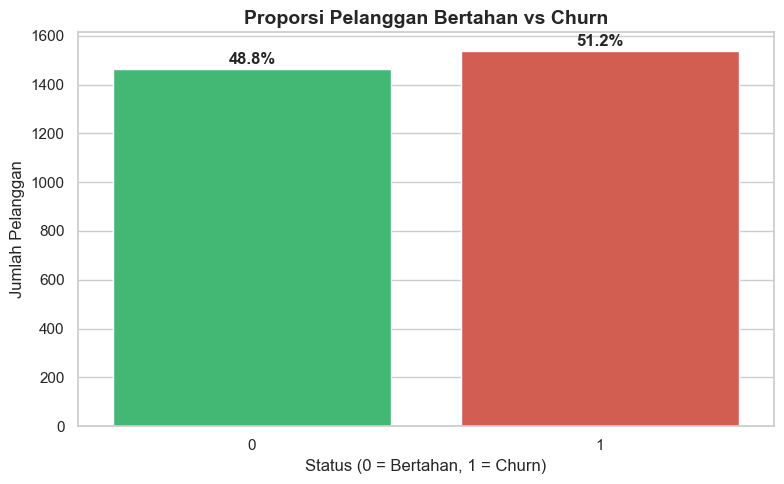


📈 VISUALISASI 2: Korelasi Fitur Terhadap Churn


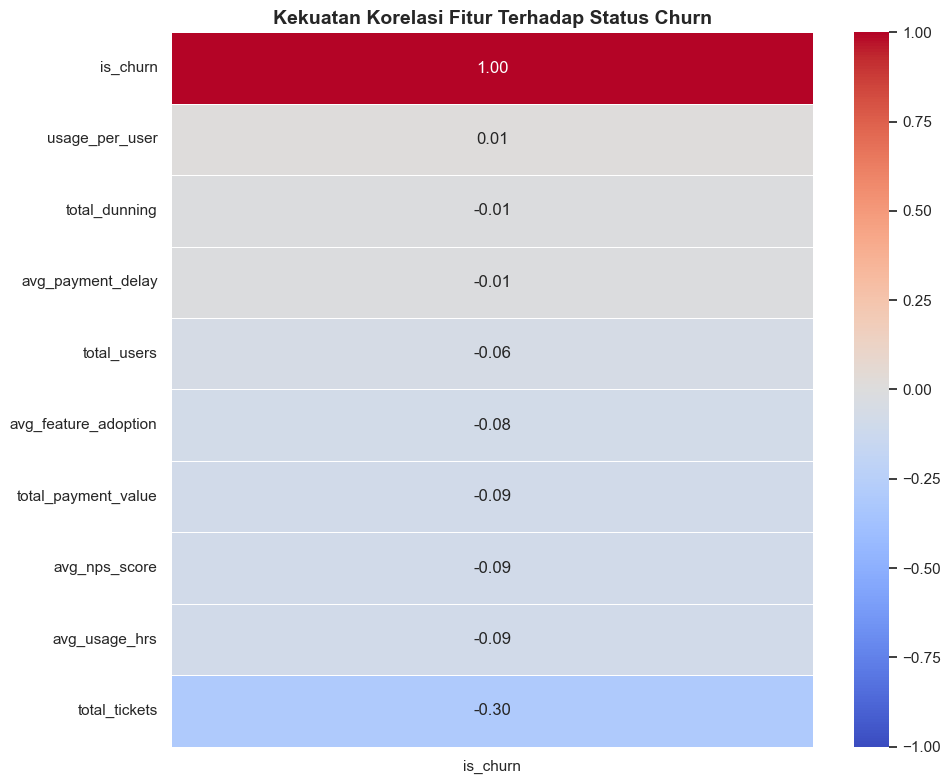

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur gaya visualisasi agar terlihat profesional
sns.set_theme(style="whitegrid")

print("="*50)
print("📊 VISUALISASI 1: Distribusi Kelas Target")
print("="*50)

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_master, x='is_churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Proporsi Pelanggan Bertahan vs Churn', fontsize=14, fontweight='bold')
plt.xlabel('Status (0 = Bertahan, 1 = Churn)', fontsize=12)
plt.ylabel('Jumlah Pelanggan', fontsize=12)

# Menambahkan anotasi persentase di atas batang diagram
total_data = len(df_master)
for p in ax.patches:
    persentase = f'{100 * p.get_height() / total_data:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 20
    ax.annotate(persentase, (x, y), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("📈 VISUALISASI 2: Korelasi Fitur Terhadap Churn")
print("="*50)

# Memilih hanya kolom bernilai numerik untuk menghindari error korelasi teks
kolom_numerik = df_master.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns
matriks_korelasi = df_master[kolom_numerik].corr()

# Membuat heatmap khusus untuk melihat hubungan fitur terhadap kolom target (is_churn)
plt.figure(figsize=(10, 8))
sns.heatmap(matriks_korelasi[['is_churn']].sort_values(by='is_churn', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', 
            linewidths=0.5, linecolor='white')
plt.title('Kekuatan Korelasi Fitur Terhadap Status Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()